<a href="https://colab.research.google.com/github/hursoo/big_k-modern_1/blob/main/gb_091_topic_in_text(big1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.개요 및 기본 설정
- 토픽과 실제 논설의 매칭
- 분석과 사료 간 대조
- 토픽모델링의 경험적 분석 도구 용도 관련

In [1]:
# =================================================================
# 셀 1: 필수 라이브러리 및 한글 폰트 설치
# =================================================================
# ⚠️ 이 셀을 실행한 후에는 반드시 "런타임 다시 시작"을 해야 합니다.

# 1. 라이브러리 설치 (최신 호환 버전)
!pip install -q tomotopy kneed

# 2. 나눔 폰트 설치
!sudo apt-get -qq install fonts-nanum*

# 3. 폰트 캐시 재생성
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("✅ 라이브러리 및 한글 폰트 설치가 완료되었습니다.")
print("🔴 중요: 지금 바로 메뉴에서 [런타임] > [세션 다시 시작]을 실행하세요!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 71.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the

Mounted at /content/drive

✅ 구글 드라이브 마운트 완료!
1.26.4
✅ 기본 설정 및 라이브러리 임포트 완료!


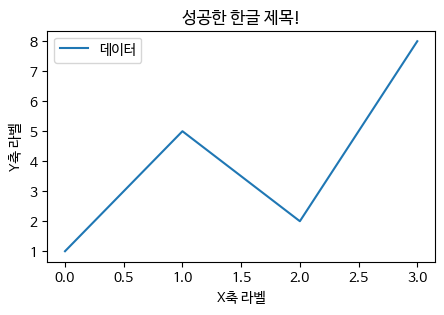

In [1]:
# =================================================================
# 셀 2: 기본 설정 및 라이브러리 임포트
# =================================================================
# "세션 다시 시작" 후에 이 셀부터 실행합니다.

# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')
print("\n✅ 구글 드라이브 마운트 완료!")

# 경로 지정
file_path = '/content/drive/MyDrive/big_km_history01/'

# 라이브러리 임포트
import sys
import os, re
import pandas as pd
import numpy as np
print(np.__version__)
import random
import warnings

from tomotopy import DMRModel
from tomotopy import TermWeight
from tomotopy import utils
import tomotopy as tp

# ⚠️ 한글 폰트 설정 코드를 여기에 배치합니다.
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic') # 나눔바른고딕으로 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("✅ 기본 설정 및 라이브러리 임포트 완료!")

# 그래프 한글 표시 테스트
plt.figure(figsize=(5, 3))
plt.title('성공한 한글 제목!')
plt.xlabel('X축 라벨')
plt.ylabel('Y축 라벨')
plt.plot([1, 5, 2, 8], label='데이터')
plt.legend()
plt.show()

# 2.데이터 불러오기

## 2.1.통합 데이터

In [2]:
# 통합 데이터 불러오기
df = pd.read_excel(file_path + 'result/gb_data_2(doc,1g2g,wn_cls).xlsx') ###
df[:3]
# 1기, 2기: doc_id는 3046부터 끝까지
df['period'] = np.where(
    df['doc_id'] < 3046,  # 조건
    'p1',                          # 조건이 참일 때
    'p2'                           # 조건이 거짓일 때
)
df

,doc_id,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls,period
0,1,創刊辭 强者도 부르짖고 弱者도 부르짖으며 優者도 부르짖고 劣者도 부르짖도다 東西南北...,창간 辭 강자 약자 優者 劣者 동서 남북 사해 팔방 소리 소리 판단 좌우 間 다수 ...,1,創刊辭,uk01,1,01q,0,p1
1,2,哲人은 말하되 多數 人民의 聲은 곳 神의 聲이라 하엿나니 神은 스스로 要求가 없는지...,哲人 다수 인민 요구 인민 소리 요구 발표 갈앙 인민 소리 갈앙 다수 인민 갈앙 요...,1,創刊辭,uk01,1,01q,0,p1
2,3,世界를 알라 사람은 天使도 안이며 野獸도 안이오 오즉 사람일 뿐이로다 이만치 進化된...,세계 사람 야수 사람 진화 진화 지식 진화 도덕 동물 세계 천당 지옥 세계 진화 국...,2,世界를 알라,uk01,1,01q,0,p1
3,4,사람과 世界는 決코 논하볼 것이 안이엇다 사람으로 된 世界 世界로 된 사람 둘이 안...,사람 세계 사람 세계 세계 사람 세계 대표 시대 가치 사람 대표 문화 상징 符號 사...,2,世界를 알라,uk01,1,01q,0,p1
4,5,過去는 論할 것이 업도다만은 今日과 가티 交通이 이마마하고 知識이 이마마하고 一切의...,過去 금일 교통 지식 일체 문물 오늘 세계 理解 공자 천하 천하 理解 오늘 날 사람...,2,世界를 알라,uk01,1,01q,0,p1
...,...,...,...,...,...,...,...,...,...,...
6797,6798,미국에서는 每人에게 奴僕이 식 돌아감니다 단 機械奴僕만 이건 무슨 말이냐 하면 기계...,미국 노복 機械 노복 機械 力 운전 계산 人力 계산 미국 국민 사람 機械 輸入 숫자...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6798,6799,매년 저축은ㅡ필요의 비용을 다 쓴 뒤의 것 말이지요ㅡ매년에 억 딸라 金 루불로는 억...,저축 필요 비용 미국 교과 書 실상 미국 富豪 캐나다 영국 미국 부분 미국 캐나다 ...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6799,6800,그러고 또 캐나다는 아조 겸손스럽게 좀 유순하게 미국의 北邊繼續이라고ㅡ국제연맹의 축...,캐나다 미국 국제_연맹 국제_연맹 원인 경제 機械 캐나다 산업 북미 자본 점령 부분...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6800,6801,25년 전에는 영국이 美보다 배나 더 되게 輸入하엿섯음니다 캐나다 사람들은 지금 그...,영국 미국 輸入 캐나다 사람 영국 一部 미국 호주 캐나다 진화 호주 일본 침입 보호...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2


In [3]:
df['r_no']

,r_no
0,1
1,1
2,2
3,2
4,2
...,...
6797,334
6798,334
6799,334
6800,334


In [ ]:
# 저장

# df.to_excel(file_path + 'result/gb_data_2(doc,1g2g,wn_cls)_period.xlsx')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6802 entries, 0 to 6801
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   doc_id            6802 non-null   int64 
 1   doc_raw           6802 non-null   object
 2   doc_split_12gram  6802 non-null   object
 3   r_no              6802 non-null   int64 
 4   title             6802 non-null   object
 5   w_new             6802 non-null   object
 6   ho_no             6802 non-null   int64 
 7   grid_1            6802 non-null   object
 8   wn_cls            6802 non-null   int64 
 9   period            6802 non-null   object
dtypes: int64(4), object(6)
memory usage: 531.5+ KB


## 2.2.문서별 토픽비중

In [5]:
# 문서별 토픽비중 불러오기

doc_dist = pd.read_csv(file_path + 'result/doc-distrib.txt', sep='\t')
doc_dist.drop(columns=['Unnamed: 0'], inplace=True)
doc_dist['doc_id'] = doc_dist.index + 1
doc_dist.set_index('doc_id', inplace=True)
doc_dist

,T0,T1,T2,T3,T4,T5,T6,T7
doc_id,,,,,,,,
1,0.100175,0.000584,0.005788,0.000916,0.699498,0.007016,0.181811,0.004213
2,0.242115,0.000204,0.016817,0.000319,0.022108,0.313191,0.403775,0.001470
3,0.013623,0.000518,0.005135,0.000812,0.357190,0.570561,0.048423,0.003738
4,0.170529,0.000538,0.005336,0.000844,0.058408,0.671052,0.089409,0.003884
5,0.701495,0.000366,0.003632,0.000575,0.066367,0.217282,0.007639,0.002644
...,...,...,...,...,...,...,...,...
6798,0.003296,0.014734,0.604653,0.085668,0.000684,0.001389,0.163286,0.126290
6799,0.004578,0.020463,0.062022,0.007873,0.000949,0.001929,0.449007,0.453179
6800,0.003746,0.016743,0.232563,0.051896,0.000777,0.001578,0.003735,0.688963


# 3.문서 속 토픽
- 문서군 단위가 효과적
- 문서군: 문서를 5개씩 묶음.  cf) 문서: 5개 문장을 단위로 함

In [6]:
df.head()

,doc_id,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls,period
0,1,創刊辭 强者도 부르짖고 弱者도 부르짖으며 優者도 부르짖고 劣者도 부르짖도다 東西南北...,창간 辭 강자 약자 優者 劣者 동서 남북 사해 팔방 소리 소리 판단 좌우 間 다수 ...,1,創刊辭,uk01,1,01q,0,p1
1,2,哲人은 말하되 多數 人民의 聲은 곳 神의 聲이라 하엿나니 神은 스스로 要求가 없는지...,哲人 다수 인민 요구 인민 소리 요구 발표 갈앙 인민 소리 갈앙 다수 인민 갈앙 요...,1,創刊辭,uk01,1,01q,0,p1
2,3,世界를 알라 사람은 天使도 안이며 野獸도 안이오 오즉 사람일 뿐이로다 이만치 進化된...,세계 사람 야수 사람 진화 진화 지식 진화 도덕 동물 세계 천당 지옥 세계 진화 국...,2,世界를 알라,uk01,1,01q,0,p1
3,4,사람과 世界는 決코 논하볼 것이 안이엇다 사람으로 된 世界 世界로 된 사람 둘이 안...,사람 세계 사람 세계 세계 사람 세계 대표 시대 가치 사람 대표 문화 상징 符號 사...,2,世界를 알라,uk01,1,01q,0,p1
4,5,過去는 論할 것이 업도다만은 今日과 가티 交通이 이마마하고 知識이 이마마하고 一切의...,過去 금일 교통 지식 일체 문물 오늘 세계 理解 공자 천하 천하 理解 오늘 날 사람...,2,世界를 알라,uk01,1,01q,0,p1


In [7]:
doc_dist.head()

,T0,T1,T2,T3,T4,T5,T6,T7
doc_id,,,,,,,,
1,0.100175,0.000584,0.005788,0.000916,0.699498,0.007016,0.181811,0.004213
2,0.242115,0.000204,0.016817,0.000319,0.022108,0.313191,0.403775,0.001470
3,0.013623,0.000518,0.005135,0.000812,0.357190,0.570561,0.048423,0.003738
4,0.170529,0.000538,0.005336,0.000844,0.058408,0.671052,0.089409,0.003884
5,0.701495,0.000366,0.003632,0.000575,0.066367,0.217282,0.007639,0.002644


## 3.1.문서군 생성
- 목적: 문서를 5개씩 묶어서 문서군을 생성
- 이유: 토픽을 실제 본문에서 확인하기 용이하게 함.
- 방식: 논설 단위. 잔여 문서 수가 3개, 4개면 독립 문서군으로, 2개 이하면 그 앞 문서군에 통합

In [8]:
import pandas as pd
import numpy as np

def create_doc_groups(df, doc_dist):
    """
    논설(r_no)별로 문서를 5개씩 묶어 '문서군'을 생성하는 함수입니다.
    """

    # doc_dist의 doc_id 인덱스 해제
    doc_dist = doc_dist.reset_index('doc_id')

    processed_groups = []

    for r_no, article_df in df.groupby('r_no'):
        docs_in_article = article_df.to_dict('records')
        num_docs = len(docs_in_article)
        temp_groups = []

        for i in range(0, num_docs, 5):
            temp_groups.append(docs_in_article[i:i+5])

        if len(temp_groups) > 1:
            last_group = temp_groups[-1]
            num_remainder = len(last_group)

            if num_remainder <= 2:
                merged_group = temp_groups[-2] + last_group
                temp_groups = temp_groups[:-2] + [merged_group]

        for group in temp_groups:
            doc_ids = [doc['doc_id'] for doc in group]
            topic_avg = doc_dist[doc_dist['doc_id'].isin(doc_ids)].iloc[:, 1:].mean()

            group_info = {
                'r_no': group[0]['r_no'],
                'title': group[0]['title'],
                'w_new': group[0]['w_new'],
                'wn_cls': group[0]['wn_cls'],
                'ho_no': group[0]['ho_no'],
                'period': group[0]['period'],
                'included_doc_ids': doc_ids,
                'doc_count': len(doc_ids),
                'doc_raw_combined': ' '.join([str(doc['doc_raw']) for doc in group]),
                # doc_split_12gram 내용을 통합하여 새 열에 추가
                'doc_split_combined': ' '.join([str(doc['doc_split_12gram']) for doc in group])
            }

            for topic, value in topic_avg.items():
                group_info[topic] = value

            processed_groups.append(group_info)

    final_df = pd.DataFrame(processed_groups)
    final_df.insert(0, '문서군_번호', range(1, len(final_df) + 1))

    return final_df

# 함수 실행
doc_groups_df = create_doc_groups(df, doc_dist)

# 결과 확인
print("생성된 문서군 데이터프레임 (상위 5개)")
print(doc_groups_df.head())

# 수정된 파일명으로 CSV 저장
output_filename = "result/gb_data_2_doc-groups.csv"
doc_groups_df.to_csv(file_path + output_filename, index=False, encoding='utf-8-sig')

print(f"\n'{output_filename}' 파일이 성공적으로 저장되었습니다.")

생성된 문서군 데이터프레임 (상위 5개)
   문서군_번호  r_no   title w_new  wn_cls  ho_no period      included_doc_ids  \
0       1     1     創刊辭  uk01       0      1     p1                [1, 2]   
1       2     2  世界를 알라  uk01       0      1     p1       [3, 4, 5, 6, 7]   
2       3     2  世界를 알라  uk01       0      1     p1    [8, 9, 10, 11, 12]   
3       4     2  世界를 알라  uk01       0      1     p1  [13, 14, 15, 16, 17]   
4       5     2  世界를 알라  uk01       0      1     p1  [18, 19, 20, 21, 22]   

   doc_count                                   doc_raw_combined  \
0          2  創刊辭 强者도 부르짖고 弱者도 부르짖으며 優者도 부르짖고 劣者도 부르짖도다 東西南北...   
1          5  世界를 알라 사람은 天使도 안이며 野獸도 안이오 오즉 사람일 뿐이로다 이만치 進化된...   
2          5  다만 오늘이라 하는 今日의 우리엇다 今日을 吟味하고 今日을 등에 진 우리엇다 今日의...   
3          5  이를 抽象的으로 말하면 正義人道의 發現이오 平等 自由의 目標라 하겟고 具體的으로 말...   
4          5  이른바 世界大勢의 順應이라 하며 世界思潮의 迎合이라 함은 今日 以後에 徹底로 나타날...   

                                  doc_split_combined        T0        T1  \
0  창간 辭 강자 약자 優者 劣者 동서 남북 사해 팔방 소리 

## 3.2.문서군, 논설명으로 접근

In [9]:
import pandas as pd

def extract_and_highlight_documents_by_id(docs_filepath, topics_filepath, doc_group_no=None, r_no=None, n=None):
    """
    지정된 문서군_번호나 r_no에 해당하는 문서를 추출하고, 토픽 단어를 강조하여 출력하는 함수입니다.

    Args:
        docs_filepath (str): 문서 그룹 데이터 파일 경로 ('gb_data_2_doc-groups.csv')
        topics_filepath (str): 토픽 단어 데이터 파일 경로 ('dmr_topics(토픽명 부착).csv')
        doc_group_no (int, optional): 필터링할 문서군_번호. 기본값은 None.
        r_no (int, optional): 필터링할 r_no. 기본값은 None.
        n (int, optional): 출력할 최대 문서군 개수. 기본값은 None (전체 출력).

    Returns:
        str: 형식에 맞게 가공된 결과 문자열. 해당하는 문서가 없으면 안내 메시지를 반환합니다.
    """
    # --- 1. 데이터 파일 읽기 ---
    try:
        topics_df = pd.read_csv(topics_filepath)
        docs_df = pd.read_csv(docs_filepath)
    except FileNotFoundError as e:
        return f"오류: 파일을 찾을 수 없습니다. {e}"

    # --- 2. 전체 토픽 단어 목록 생성 ---
    all_topic_words = set()
    topic_word_dict = {} # 각 토픽별 단어를 저장할 딕셔너리

    topic_cols = [f'T{i}' for i in range(len(topics_df))]  ###

    for _, row in topics_df.iterrows():
        topic_name = f"T{row['Topic_Index']}"  ###
        words = {word.strip() for word in row['Top_Words'].split(',')}
        all_topic_words.update(words)
        topic_word_dict[topic_name] = words

    # --- 3. 매개변수에 따른 문서 데이터 필터링 ---
    filtered_df = docs_df.copy()

    # doc_group_no 또는 r_no로 필터링
    if doc_group_no is not None:
        filtered_df = filtered_df[filtered_df['문서군_번호'] == doc_group_no]

    if r_no is not None:
        filtered_df = filtered_df[filtered_df['r_no'] == r_no]

    # --- 4. 결과 문자열 생성 ---
    if filtered_df.empty:
        return f"결과 없음: 해당 조건(문서군_번호: {doc_group_no}, r_no: {r_no})의 문서가 없습니다."

    # 출력 개수(n) 제한 적용
    if n is not None and isinstance(n, int) and n > 0:
        display_df = filtered_df.head(n)
    else:
        display_df = filtered_df

    output_string = ""
    for _, row in display_df.iterrows():
        # 해당 문서의 주 토픽(dominant topic)을 찾음
        dominant_topic = row[topic_cols].idxmax()
        target_topic_words = topic_word_dict.get(dominant_topic, set())

        # 'doc_split_combined' 내용에서 토픽 단어 강조
        doc_words = row['doc_split_combined'].split(' ')
        highlighted_words = []
        for word in doc_words:
            if word in target_topic_words:
                highlighted_words.append(f"**{word}**")
            elif word in all_topic_words:
                highlighted_words.append(f"*{word}*")
            else:
                highlighted_words.append(word)
        highlighted_doc = ' '.join(highlighted_words)

        # 각 문서군의 정보를 문자열에 추가
        output_string += f"문서군_번호: {row['문서군_번호']}\n"
        output_string += f"r_no: {row['r_no']}\n"
        output_string += f"title: {row['title']}\n"
        output_string += f"w_new: {row['w_new']}\n"
        output_string += f"wn_cls: {row['wn_cls']}\n"
        output_string += f"ho_no: {row['ho_no']}\n"
        output_string += f"period: {row['period']}\n"
        output_string += f"included_doc_ids: {row['included_doc_ids']}\n"
        output_string += f"doc_count: {row['doc_count']}\n"
        output_string += f"doc_raw_combined: {row['doc_raw_combined']}\n"
        output_string += f"doc_split_combined: {highlighted_doc}\n"
        output_string += "-----\n"

    return output_string

# --- 함수 실행 예시 ---
if __name__ == "__main__":
    # 파일 경로는 실제 파일 위치에 맞게 수정해야 합니다.
    DOCS_FILE = file_path + 'result/gb_data_2_doc-groups.csv'
    TOPICS_FILE = file_path + 'result/dmr_topics(토픽명 부착).csv'

    # --- 예시 1: 문서군_번호가 190인 문서 출력 ---
    print("--- 예시 1: 문서군_번호가 190인 결과 ---")
    result_1 = extract_and_highlight_documents_by_id(
        docs_filepath=DOCS_FILE,
        topics_filepath=TOPICS_FILE,
        doc_group_no=190, ###
        r_no=53 ###
    )
    print(result_1)

--- 예시 1: 문서군_번호가 190인 결과 ---
문서군_번호: 190
r_no: 53
title: 社會問題에 先하야 自我問題에 反하라. 그리하야 社會에 對한 公僕이 되라
w_new: 박달성
wn_cls: 1
ho_no: 12
period: p1
included_doc_ids: [928, 929, 930, 931, 932]
doc_count: 5
doc_raw_combined: 아 現代人아 自己를 確實히 알앗거든 人生의 如何를 深切히 覺悟하얏거든 萬人平等을 事實로 느꼇거든 覺悟한 그대로 느낀 그대로 各自 스스로가 몸소 實行하라 이써 나에 呌苦하는 問題의 세 번재이다 4 過去의 非와 今後의 是 人生의 目的이 快樂이라 하면 人生으로서는 老者 壯者 少者 男子 女子 兒童까지 누구나 다 快樂을 要求할 것이다 然한데 웨 어떤 者는 快樂의 座에서 歡喜의 웃음을 웃으며 웨 어떤者는 悲哀의 窟에서 苦痛의 눈물을 흘리고 잇는가 나는 써하되 悲哀者 스스로의 罪라 한다 人生의 目的이 功利이라 하면 또한 다 功利의 人이 되어야 되겟다 그런데 어떤 놈은 功利의 榮冠을 쓰고 어떤 놈은 退敗의 悲曲을 부르니 이것은 또한 누의 罪이겟는가 決코 功利者의 罪는 아니라 한다 人生의 目的이 自己充實이면 이도 또한 人生 全體가 다 充實하여야겟거늘 어떤 者는 充實하고 어떤 者는 不充實하니 이 또한 不充實者 스스로의 罪가 아니냐 가튼 사람으로 가튼 欲望으로 왜 快樂치 못하며 功利치 못하며 充實치 못하얏느냐 彼等의 快樂 彼等의 功利 彼等에 充實은 彼等 스스로가 努力하야 어든 것이며 또한 이 不快樂者 不功利者 不充實者로서 보내 준 것이며 도아 준 것이다 다시 말하면 彼가 快樂키 爲하야 高臺를 築하며 奴僕을 募하거늘 此로서는 勞役者가 되어 주며 奴僕으로 自進한 것이 아니냐 大將은 功利를 爲하야 만흔 犧牲을 要求하거늘 兵卒은 그 功利를 助力키 爲하야 水火自進한 것이 아니냐 彼는 知者이오 覺者이오 實力者이거늘 此는 웨 迷者며 愚者며 無力者인가 吾人은 權力家를 만히 罵倒하며 富貴者를 만히 彈劾하며 無勢力者를 

## 3.3.필자분류, 토픽명으로 접근

### 검토대상 문서군 추출

In [10]:
import pandas as pd

def get_topic_distribution(
    filepath,
    topic_no=None,
    w_new=None,
    doc_id=None,
    wn_cls=None,
    n=5
):
    """
    CSV 파일을 불러와 조건에 맞게 필터링하고, 특정 토픽 분포를 기준으로
    내림차순 정렬하여 상위 n개의 결과를 DataFrame으로 반환하는 함수입니다.

    Args:
        filepath (str): 불러올 CSV 파일의 경로.
        topic_no (str, optional): 정렬의 기준이 될 토픽 번호 (예: 'T3').
                                  None이면 정렬하지 않음. 기본값은 None.
        w_new (str, optional): 필터링할 필자명. 기본값은 None.
        doc_id (int, optional): 필터링할 논설 고유번호(r_no). 기본값은 None.
        wn_cls (int, optional): 필터링할 필자 분류. 기본값은 None.
        n (int, optional): 추출할 상위 결과의 개수. 기본값은 5.

    Returns:
        pandas.DataFrame: 조건에 맞게 필터링되고 정렬된 결과 데이터프레임.
    """
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"오류: '{filepath}' 파일을 찾을 수 없습니다.")
        return None

    filtered_df = df.copy()

    # 매개변수 값에 따라 데이터 필터링
    if w_new is not None:
        filtered_df = filtered_df[filtered_df['w_new'] == w_new]

    if doc_id is not None:
        filtered_df = filtered_df[filtered_df['r_no'] == doc_id]

    if wn_cls is not None:
        filtered_df = filtered_df[filtered_df['wn_cls'] == wn_cls]

    # 지정된 토픽 번호로 내림차순 정렬
    topic_cols = [col for col in df.columns if col.startswith('T')]
    if topic_no is not None and topic_no in topic_cols:
        filtered_df = filtered_df.sort_values(by=topic_no, ascending=False)

    # 상위 n개 결과 추출 및 최종 컬럼 선택 (***수정된 부분***)
    result_cols = ['문서군_번호', 'r_no', 'title', 'w_new', 'wn_cls'] + topic_cols
    result_df = filtered_df.head(n)[result_cols]

    return result_df

# --- 함수 실행 예시 ---
if __name__ == "__main__":
    FILE_PATH = file_path + 'result/gb_data_2_doc-groups.csv'

    print("--- 예시: 필자 분류(wn_cls)가 1인 문서 중, T4 토픽 점수가 가장 높은 상위 5개 ---")  ###
    example_df = get_topic_distribution(
        filepath=FILE_PATH,
        wn_cls=1, ###
        topic_no='T4', ###
        n=5
    )
    print(example_df)

--- 예시: 필자 분류(wn_cls)가 1인 문서 중, T4 토픽 점수가 가장 높은 상위 5개 ---
     문서군_번호  r_no                                              title w_new  \
189     190    53            社會問題에 先하야 自我問題에 反하라. 그리하야 社會에 對한 公僕이 되라   박달성   
51       52    13                        從來의 孝道를 批判하야써 今後의 父子關係를 聲言함   김기전   
260     261    71  生活의 條件을 本位로 한 朝鮮의 改造事業, 이 글을 特히 民族의 盛衰를 雙肩에 負한...   이돈화   
307     308    79                           現代倫理思想의 槪觀, 東洋式 倫理思想의 變遷   이돈화   
50       51    13                        從來의 孝道를 批判하야써 今後의 父子關係를 聲言함   김기전   

     wn_cls        T0        T1        T2        T3        T4        T5  \
189       1  0.019468  0.006111  0.002229  0.002148  0.834694  0.030436   
51        1  0.078313  0.000468  0.005727  0.000320  0.819455  0.011296   
260       1  0.048754  0.023279  0.011675  0.008115  0.816075  0.057423   
307       1  0.113072  0.000452  0.000950  0.032634  0.795598  0.040301   
50        1  0.123677  0.000510  0.002058  0.000349  0.786838  0.002251   

           T6        T

In [ ]:
example_df

,문서군_번호,r_no,title,w_new,wn_cls,T0,T1,T2,T3,T4,T5,T6,T7
189,190,53,社會問題에 先하야 自我問題에 反하라. 그리하야 社會에 對한 公僕이 되라,박달성,1,0.019468,0.006111,0.002229,0.002148,0.834694,0.030436,0.103780,0.001133
51,52,13,從來의 孝道를 批判하야써 今後의 父子關係를 聲言함,김기전,1,0.078313,0.000468,0.005727,0.000320,0.819455,0.011296,0.083374,0.001047
260,261,71,"生活의 條件을 本位로 한 朝鮮의 改造事業, 이 글을 特히 民族의 盛衰를 雙肩에 負한...",이돈화,1,0.048754,0.023279,0.011675,0.008115,0.816075,0.057423,0.024647,0.010032
307,308,79,"現代倫理思想의 槪觀, 東洋式 倫理思想의 變遷",이돈화,1,0.113072,0.000452,0.000950,0.032634,0.795598,0.040301,0.016672,0.000322
50,51,13,從來의 孝道를 批判하야써 今後의 父子關係를 聲言함,김기전,1,0.123677,0.000510,0.002058,0.000349,0.786838,0.002251,0.078059,0.006257


### 세부조건 부여
- 상위n개

In [12]:
import pandas as pd

def extract_and_highlight_documents(docs_filepath, topics_filepath, target_w_cls, target_topic, n=None):
    """
    지정된 필자 분류와 토픽에 해당하는 문서를 추출하고, 토픽 단어를 강조하여 출력하는 함수입니다.

    Args:
        docs_filepath (str): 문서 그룹 데이터 파일 경로 ('gb_data_2_doc-groups.csv')
        topics_filepath (str): 토픽 단어 데이터 파일 경로 ('dmr_topics(토픽명 부착).csv')
        target_w_cls (int): 필터링할 필자 분류 번호 (wn_cls)
        target_topic (str): 필터링할 토픽 이름 (예: 'T3')
        n (int, optional): 출력할 최대 문서군 개수. 기본값은 None (전체 출력).

    Returns:
        str: 형식에 맞게 가공된 결과 문자열. 해당하는 문서가 없으면 안내 메시지를 반환합니다.
    """
    # --- 1. 데이터 파일 읽기 ---
    try:
        topics_df = pd.read_csv(topics_filepath)
        docs_df = pd.read_csv(docs_filepath)
    except FileNotFoundError as e:
        return f"오류: 파일을 찾을 수 없습니다. {e}"

    # --- 2. 토픽 단어 처리 ---
    all_topic_words = set()
    target_topic_words = set()

    for _, row in topics_df.iterrows():
        words = {word.strip() for word in row['Top_Words'].split(',')}
        all_topic_words.update(words)
        if f"T{row['Topic_Index']}" == target_topic:
            target_topic_words.update(words)

    # --- 3. 문서 데이터 처리 및 필터링 ---
    topic_cols = [f'T{i}' for i in range(0, 7)]
    docs_df['dominant_topic'] = docs_df[topic_cols].idxmax(axis=1)

    filtered_df = docs_df[
        (docs_df['wn_cls'] == target_w_cls) &
        (docs_df['dominant_topic'] == target_topic)
    ].copy() # SettingWithCopyWarning 방지를 위해 .copy() 사용

    # --- 4. 결과 문자열 생성 ---
    if filtered_df.empty:
        return f"결과 없음: 필자 분류 '{target_w_cls}'와 토픽 '{target_topic}'에 해당하는 문서가 없습니다."

    # >>>>> 변경 시작 <<<<<
    # 지정된 토픽(target_topic)의 점수를 기준으로 내림차순 정렬
    sorted_df = filtered_df.sort_values(by=target_topic, ascending=False)

    # 정렬된 결과에서 출력 개수(n) 제한 적용
    if n is not None and isinstance(n, int) and n > 0:
        display_df = sorted_df.head(n)
    else:
        display_df = sorted_df
    # >>>>> 변경 끝 <<<<<

    output_string = ""
    for _, row in display_df.iterrows():
        # 'doc_split_combined' 내용에서 토픽 단어 강조 (로직 수정)
        doc_words = row['doc_split_combined'].split(' ')
        highlighted_words = []
        for word in doc_words:
            # 1순위: 지정된 토픽의 단어는 **로 강조
            if word in target_topic_words:
                highlighted_words.append(f"**{word}**")
            # 2순위: 그 외 다른 토픽의 단어는 *로 강조
            elif word in all_topic_words:
                highlighted_words.append(f"*{word}*")
            # 3순위: 토픽 단어가 아니면 그대로 추가
            else:
                highlighted_words.append(word)
        highlighted_doc = ' '.join(highlighted_words)

        # 각 문서군의 정보를 문자열에 추가
        output_string += f"문서군_번호: {row['문서군_번호']}\n"
        output_string += f"r_no: {row['r_no']}\n"
        output_string += f"title: {row['title']}\n"
        output_string += f"w_new: {row['w_new']}\n"
        output_string += f"wn_cls: {row['wn_cls']}\n"
        output_string += f"ho_no: {row['ho_no']}\n"
        output_string += f"period: {row['period']}\n"
        output_string += f"included_doc_ids: {row['included_doc_ids']}\n"
        output_string += f"doc_count: {row['doc_count']}\n"
        output_string += f"doc_raw_combined: {row['doc_raw_combined']}\n"
        output_string += f"doc_split_combined: {highlighted_doc}\n"
        output_string += "-----\n"

    return output_string

# --- 함수 실행 예시 ---
if __name__ == "__main__":
    # 파일 경로
    DOCS_FILE = file_path + 'result/gb_data_2_doc-groups.csv'
    TOPICS_FILE = file_path + 'result/dmr_topics(토픽명 부착).csv'

    # --- 예시 1: wn_cls=2, topic=T3인 문서 전체 출력 ---
    print("--- 예시 1: wn_cls=2, topic='T3' 상위 3개 결과 ---")
    result_1 = extract_and_highlight_documents(
        docs_filepath=DOCS_FILE,
        topics_filepath=TOPICS_FILE,
        target_w_cls=2,
        target_topic='T3',
        n=3  # 출력 개수
    )
    print(result_1)

--- 예시 1: wn_cls=2, topic='T3' 상위 3개 결과 ---
문서군_번호: 1363
r_no: 331
title: 新興政治運動의 性質, 全的 運動과 部分的 運動의 分野
w_new: 배성룡
wn_cls: 2
ho_no: 72
period: p2
included_doc_ids: [6756, 6757, 6758, 6759, 6760, 6761, 6762]
doc_count: 7
doc_raw_combined: 新興政治運動의 性質 全的 運動과 部分的 運動의 分野 부르주아 사회는 이 사회를 부르주아 들이 지배하고 잇다는 것을 의미함이다 부르주아 사회의 역사적 발전에 의한 사회변혁이 잇기 전에 그 내부에서 발생하고 생장 발달하는 한가지 質의 다른 세력은 이 프롤레타리아의 신흥세력이니 현대에 잇서 가장 큰 함성으로 전세계를 진동하는 사회운동은 그 프롤레타리아 세력의 發動을 다른 말로 命名한 것이다 사회운동은 부르주아 사회의 내부에서 미래의 아름다운 사회를 신속히 건설하랴는 프롤레타리아의 새로 대두한 노력이다 부르주아 사회의 모든 제도와 조직을 그대로 둘 수 업다는 의미에서 그 질과 형식의 다른 무엇으로 고치라는 것이 그 유일한 목적이니 말하자면 부르주아 사회를 하랴는 운동이다 그럼으로 사회운동의 목표하는 대상은 그 자본주의사회라는 한 덩어리가 되야 잇는 한 개의 渾一的 勢力이니 그 내부에 넛코 잇고 싸고 잇스며 얼거매고 만드러 두고 붓처노흔 모든 정치와 경제사실 도덕과 법률에 관한 사실의 그 어느 것도 그 운동의 대상이 아니 됨이 업슬 것도 물론이다 그 운동의 범위가 그만치 광범하고 그 운동의 목적이 그만치 浩大함을 따라서 그 역사적 변혁의 途程에서 요하는 時問도 상당히 긴 것이라 그 行程은 결코 一朝一夕에 통과할 수 업는 것이다 여긔에서 사회운동은 그 내용이 복잡하야짐을 따라서 각개의 운동부문으로 분화하게 되고 그 범위가 확대됨을 따라서 질적 변동에 의한 각개의 생장계단이 잇게 되는 것이니 그 운동이 질적 양적의 양 방면으로 間斷업시 변동되야 一部門的의

In [13]:
# 바로 위 결과의 토픽 분포 파악 (이전 사용자 함수 활용)

# --- 함수 실행 예시 ---
if __name__ == "__main__":
    FILE_PATH = file_path + 'result/gb_data_2_doc-groups.csv'

    print("--- 예시: 필자 분류(wn_cls)가 2인 문서 중, T3 토픽 점수가 가장 높은 상위 3개 ---")  ###
    example_df = get_topic_distribution(
        filepath=FILE_PATH,
        wn_cls=2, ###
        topic_no='T3', ###
        n=5
    )
    print(example_df)

--- 예시: 필자 분류(wn_cls)가 2인 문서 중, T3 토픽 점수가 가장 높은 상위 3개 ---
      문서군_번호  r_no                           title w_new  wn_cls        T0  \
1362    1363   331   新興政治運動의 性質, 全的 運動과 部分的 運動의 分野   배성룡       2  0.001213   
765      766   189                    國際無産靑年運動과 朝鮮   주종건       2  0.024972   
1242    1243   301            勞資戰의 埒外에 立한 中産階級의 將來   배성룡       2  0.003137   
1336    1337   325  朝鮮思想運動者들의 階級的組成을 推究하면서, 朝鮮의 熟慮   박진순       2  0.038412   
1185    1186   287                  世界農民運動의 過去와 現在   박진순       2  0.047624   

            T1        T2        T3        T4        T5        T6        T7  
1362  0.012311  0.026751  0.937920  0.000252  0.000511  0.008038  0.013004  
765   0.000310  0.001151  0.813693  0.002513  0.021935  0.005457  0.129969  
1242  0.000222  0.078618  0.809972  0.060374  0.036720  0.002755  0.008202  
1336  0.016159  0.070509  0.809621  0.000564  0.001146  0.030619  0.032969  
1185  0.000656  0.084385  0.804574  0.006789  0.010634  0.017253  0.028084  


## 3.4.엠에디터로 확인: 마커 기능
- 엠에디터로 이동

# The End of Note